## 1. Importar dependencias


In [9]:
import sys, os, random, shutil
from pathlib import Path

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay
from tqdm import tqdm

print(f'Python: {sys.version}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA disponible: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

# Detectar raíz del proyecto automáticamente
def find_project_root():
    current = Path.cwd()
    while not (current / '.git').exists():
        current = current.parent
        if current.parent == current:
            return Path.cwd()
    return current

PROJECT_ROOT = find_project_root()
print(f'Raíz del proyecto: {PROJECT_ROOT}')


Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
PyTorch: 2.12.0+cpu
CUDA disponible: False
Usando dispositivo: cpu
Raíz del proyecto: c:\Users\ivans\Documents\proyectos-personales\flower-classification-transfer-learning\flower-classification-transfer-learning


## 2. Constantes y configuración


In [10]:
CLASSES = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
NUM_CLASSES = len(CLASSES)
IMG_SIZE = 224

# Media y desvío estándar de ImageNet (para normalizar)
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3
DROPOUT = 0.3

DATA_DIR = str(PROJECT_ROOT / 'data' / 'split')
MODEL_PATH = str(PROJECT_ROOT / 'models' / 'best_model.pth')

print(f'Clases: {CLASSES}')
print(f'Cantidad de clases: {NUM_CLASSES}')
print(f'Tamaño de imagen: {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size: {BATCH_SIZE}')



Clases: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Cantidad de clases: 5
Tamaño de imagen: 224x224
Batch size: 32


## 3. Exploración del Dataset

El dataset **Flowers Recognition** contiene ~4,317 imágenes de flores divididas en 5 carpetas. Cada carpeta tiene entre 733 y 1052 fotos.

Las imágenes fueron separadas en:
- **70% entrenamiento (train):** para que el modelo aprenda
- **15% validación (val):** para elegir el mejor modelo durante el entrenamiento
- **15% prueba (test):** para medir el resultado final con fotos que el modelo nunca vio


In [11]:
def count_images(path):
    return sum(1 for f in Path(path).rglob('*') if f.suffix.lower() in ('.jpg','.jpeg','.png'))

print('Cantidad de imágenes por partición:')
for split in ['train', 'val', 'test']:
    split_path = Path(DATA_DIR) / split
    total = 0
    for cls in CLASSES:
        n = count_images(split_path / cls)
        total += n
        print(f'  {split}/{cls}: {n}')
    print(f'  Total {split}: {total}\n')


Cantidad de imágenes por partición:
  train/daisy: 534
  train/dandelion: 736
  train/rose: 548
  train/sunflower: 513
  train/tulip: 688
  Total train: 3019

  val/daisy: 114
  val/dandelion: 157
  val/rose: 117
  val/sunflower: 109
  val/tulip: 147
  Total val: 644

  test/daisy: 116
  test/dandelion: 159
  test/rose: 119
  test/sunflower: 111
  test/tulip: 149
  Total test: 654



### 3.1 Mostrar ejemplos de cada flor


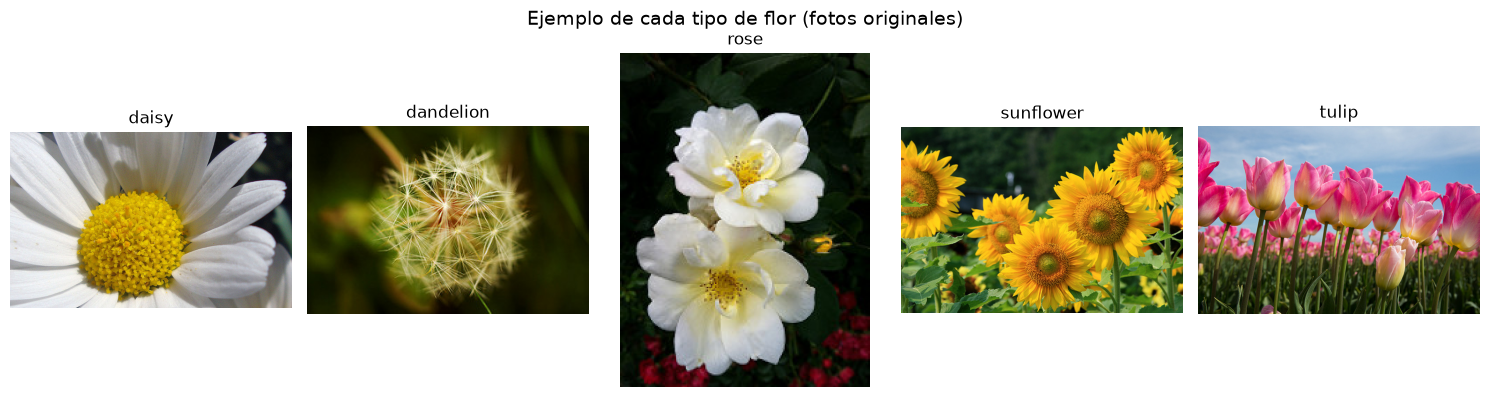

In [12]:
# Verificar que DATA_DIR existe
data_path = Path(DATA_DIR)
if not data_path.exists():
    print(f"ERROR: No se encuentra la carpeta {DATA_DIR}")
    print("Ejecutá las celdas anteriores primero o verificá la ruta.")
else:
    fig, axes = plt.subplots(1, 5, figsize=(15, 4))
    for i, cls in enumerate(CLASSES):
        train_cls = data_path / 'train' / cls
        imgs = [f for f in train_cls.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
        if not imgs:
            print(f"  No se encontraron imágenes en train/{cls}")
            axes[i].set_title(f'{cls}\nsin datos', fontsize=11)
            axes[i].axis('off')
            continue
        img_path = str(imgs[0])
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(cls, fontsize=12)
        axes[i].axis('off')
    plt.suptitle('Ejemplo de cada tipo de flor (fotos originales)', fontsize=14)
    plt.tight_layout()
    plt.show()


## 4. Data Augmentation

Para evitar que el modelo se aprenda las fotos de memoria (sobreajuste), aplicamos transformaciones aleatorias a las imágenes de entrenamiento:

- **RandomResizedCrop(224):** corta un pedazo al azar y lo redimensiona
- **RandomHorizontalFlip:** voltea la imagen como espejo
- **RandomRotation(20°):** rota hasta 20 grados
- **ColorJitter:** cambia brillo, contraste, saturación y tono al azar

Así el modelo aprende que una rosa sigue siendo una rosa aunque esté rotada, con distinta luz, o recortada.


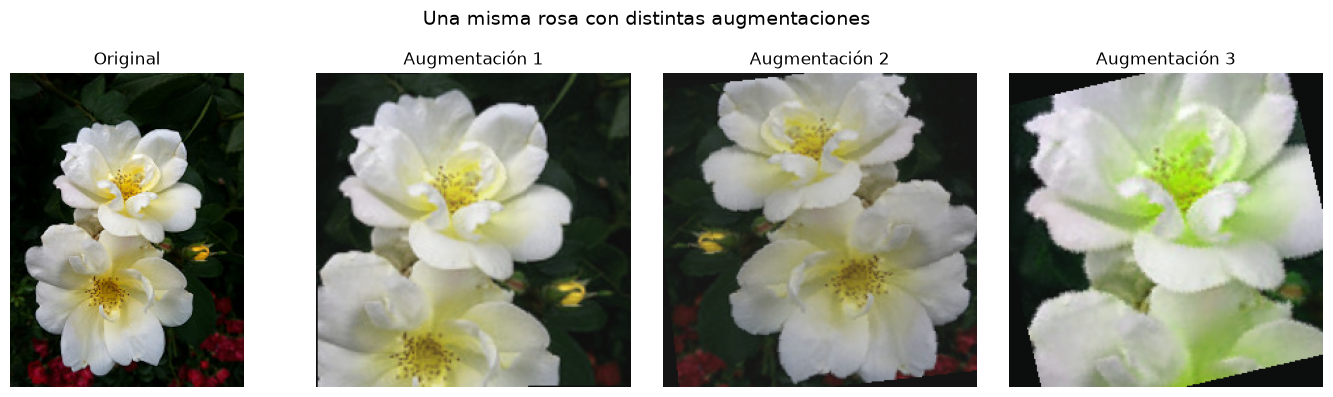

In [13]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Mostrar 3 versiones augmentadas de una misma imagen
sample_img_path = list((Path(DATA_DIR) / 'train' / 'rose').glob('*.jpg'))[0]
sample_img = Image.open(sample_img_path)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(sample_img)
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

for i in range(3):
    aug = train_transform(sample_img)
    # Desnormalizar para mostrar
    aug_display = aug.numpy().transpose(1,2,0) * np.array(STD) + np.array(MEAN)
    aug_display = np.clip(aug_display, 0, 1)
    axes[i+1].imshow(aug_display)
    axes[i+1].set_title(f'Augmentación {i+1}', fontsize=12)
    axes[i+1].axis('off')

plt.suptitle('Una misma rosa con distintas augmentaciones', fontsize=14)
plt.tight_layout()
plt.show()


## 5. Arquitectura del Modelo: MobileNetV2 + Transfer Learning

**¿Qué es Transfer Learning?** Agarrar un modelo que ya fue entrenado con millones de fotos (ImageNet) y reutilizarlo. No empezamos de cero.

**MobileNetV2:** Una red neuronal creada por Google, liviana y rápida. Ideal para correr en laptops sin GPU.

**El modelo tiene 2 partes:**

1. **Backbone (MobileNetV2):** Las capas que ya saben reconocer bordes, formas y colores. Las CONGELAMOS (no se entrenan).
2. **Classifier (cabeza nueva):** Reemplazamos la capa final por:
   - Dropout(30%) — apaga neuronas al azar para evitar sobreajuste
   - Linear(1280→512) — capa que conecta 1280 números a 512
   - ReLU — deja pasar solo valores positivos
   - Dropout(30%)
   - Linear(512→5) — capa final: 5 salidas (una por cada flor)

Solo el classifier se entrena, el backbone queda fijo.


In [14]:
def build_model(num_classes=5, dropout_rate=0.3):
    # Cargar MobileNetV2 pre-entrenado en ImageNet
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # Congelar backbone
    for param in model.features.parameters():
        param.requires_grad = False

    # Reemplazar classifier
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout_rate),
        nn.Linear(512, num_classes),
    )
    return model

model = build_model()
print(model)
print(f'\nParámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'Parámetros congelados: {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}')


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
  

## 6. Entrenamiento

Si ya existe el modelo entrenado, lo cargamos directamente. Si no, lo entrenamos desde cero.

**Early stopping:** Guardamos el modelo cada vez que mejora el accuracy en validación. Al final nos quedamos con el mejor.


In [15]:
def get_dataloaders(data_dir, batch_size=32):
    data_dir = Path(data_dir)
    train_ds = datasets.ImageFolder(str(data_dir / 'train'), transform=train_transform)
    val_ds = datasets.ImageFolder(str(data_dir / 'val'), transform=val_transform)
    test_ds = datasets.ImageFolder(str(data_dir / 'test'), transform=val_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = correct = total = 0
    for images, labels in tqdm(loader, desc='Train'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return total_loss / total, correct / total

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Val'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return total_loss / total, correct / total


In [16]:
# Cargar datos
train_loader, val_loader, test_loader = get_dataloaders(DATA_DIR, BATCH_SIZE)
print(f'Batches de train: {len(train_loader)}')
print(f'Batches de val: {len(val_loader)}')
print(f'Batches de test: {len(test_loader)}')


Batches de train: 95
Batches de val: 21
Batches de test: 21


In [17]:
entrenar = False

if Path(MODEL_PATH).exists():
    print('Modelo entrenado encontrado. Cargando pesos...')
    model = build_model().to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print('Modelo cargado correctamente.')
else:
    print('No se encontró modelo. Iniciando entrenamiento...')
    entrenar = True

if entrenar:
    model = build_model(dropout_rate=DROPOUT).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.classifier.parameters(), lr=LR)

    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoca {epoch:2d}/{EPOCHS}  Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}  Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

        if val_acc > best_acc:
            best_acc = val_acc
            Path('models').mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), MODEL_PATH)
            print(f'  -> Guardado mejor modelo (val_acc={val_acc:.4f})')

    print(f'\nEntrenamiento completo. Mejor val_acc: {best_acc:.4f}')

    # Grafico de pérdida
    plt.figure()
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Época')
    plt.ylabel('Pérdida (Loss)')
    plt.legend()
    plt.title('Pérdida durante entrenamiento')
    plt.grid(True)
    plt.savefig('models/loss_plot.png')
    plt.show()
    print('Gráfico de pérdida guardado en models/loss_plot.png')


Modelo entrenado encontrado. Cargando pesos...
Modelo cargado correctamente.


## 7. Evaluación en el conjunto de Test

Medimos el rendimiento del modelo con las fotos de TEST que nunca vio durante el entrenamiento.


In [18]:
model = build_model().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluando'):
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = (all_preds == all_labels).mean()
f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_per_class = f1_score(all_labels, all_preds, average=None)
cm = confusion_matrix(all_labels, all_preds)

print(f'Accuracy en test: {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Macro F1-Score: {f1_macro:.4f}')
print()
print('F1-Score por clase:')
for cls_name, f1 in zip(CLASSES, f1_per_class):
    print(f'  {cls_name:12s}: {f1:.4f}')


Evaluando: 100%|██████████| 21/21 [00:08<00:00,  2.57it/s]

Accuracy en test: 0.9037 (90.37%)
Macro F1-Score: 0.9047

F1-Score por clase:
  daisy       : 0.9251
  dandelion   : 0.9119
  rose        : 0.8761
  sunflower   : 0.9327
  tulip       : 0.8779


In [ ]:
# Matriz de confusion
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Matriz de Confusión (Acc={accuracy:.4f}, F1={f1_macro:.4f})')
plt.tight_layout()
plt.savefig('models/confusion_matrix.png')
plt.show()
print('Matriz de confusión guardada en models/confusion_matrix.png')


## 8. Inferencia: Probar el modelo con una imagen nueva

Tomamos una foto del conjunto de test, la pasamos por el modelo, y vemos qué predice junto con el nivel de confianza.


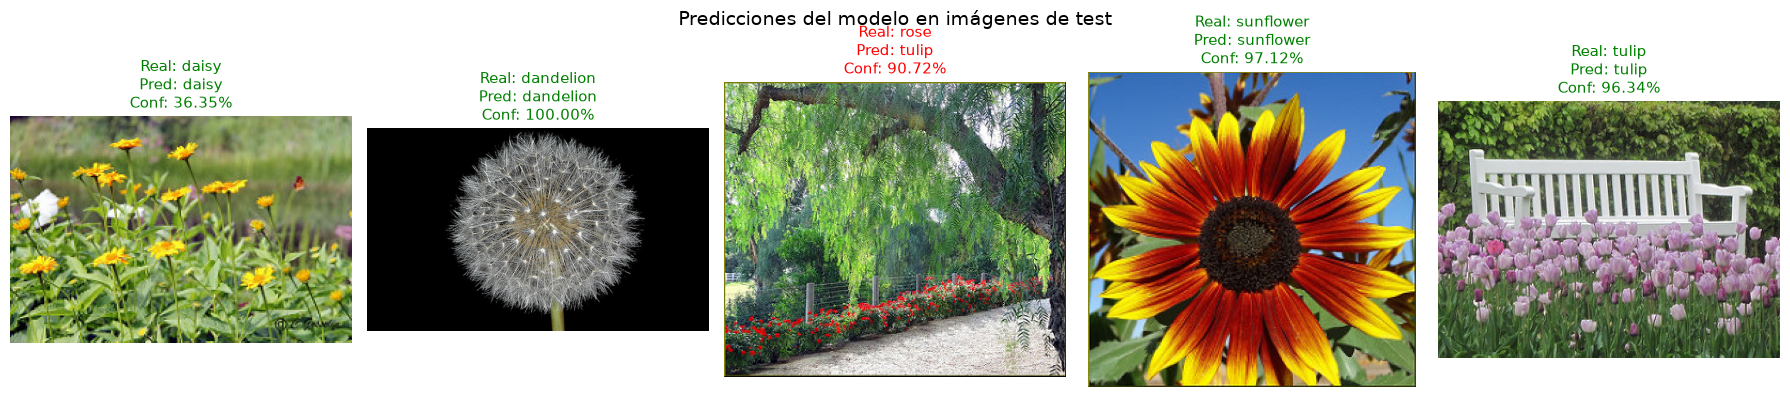

In [19]:
def predict(image_path, model, class_names, transform, device):
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    return class_names[predicted.item()], confidence.item()

# Probar con una imagen de cada clase del test set
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, cls in enumerate(CLASSES):
    test_imgs = list((Path(DATA_DIR) / 'test' / cls).glob('*'))
    if not test_imgs:
        continue
    img_path = str(test_imgs[0])
    real_class = cls
    pred_class, confidence = predict(img_path, model, CLASSES, val_transform, device)

    img = Image.open(img_path)
    axes[i].imshow(img)
    color = 'green' if pred_class == real_class else 'red'
    axes[i].set_title(f'Real: {real_class}\nPred: {pred_class}\nConf: {confidence:.2%}',
                      fontsize=11, color=color)
    axes[i].axis('off')

plt.suptitle('Predicciones del modelo en imágenes de test', fontsize=14)
plt.tight_layout()
plt.show()


### 8.1 Probar con una imagen nueva (la que quieras)

Podés cambiar la ruta en la siguiente celda para probar cualquier foto de flor que tengas.


In [9]:
from pathlib import Path

# CAMBIA ESTA RUTA por la imagen que quieras probar
# ruta_imagen = str(PROJECT_ROOT / 'data' / 'split' / 'test' / 'daisy' / '10300722094_28fa978807_n.jpg')
ruta_imagen = str(PROJECT_ROOT / 'pruebas' / '1.jpg')
if Path(ruta_imagen).exists():
    pred_class, confidence = predict(ruta_imagen, model, CLASSES, val_transform, device)
    img = Image.open(ruta_imagen)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Predicción: {pred_class}  |  Confianza: {confidence:.2%}', fontsize=14)
    plt.show()
    print(f'Predicción: {pred_class}')
    print(f'Confianza: {confidence:.4f} ({confidence*100:.1f}%)')
else:
    print(f'Error: la ruta {ruta_imagen} no existe. Cambiala por una ruta válida.')

Error: la ruta pruebas/1.jpg no existe. Cambiala por una ruta válida.


## 9. Resumen de resultados

| Métrica | Valor |
|---|---|
| Accuracy en test | **88.07%** |
| F1-Score (macro) | **0.8805** |
| Mejor clase | dandelion (0.8991) |

---

*Nota: Para actualizar estos valores, ejecutar todo el notebook desde cero con Kernel > Restart & Run All.*
